# FreqLoRA-SAM: Frequency-Enhanced Low-Rank Adaptation of Segment Anything for Polyp Segmentation

**This notebook runs the complete experimental pipeline:**

| Part | Description |
|------|-------------|
| **A** | Shared setup: imports, paths, FreqLoRA / LoRA definitions, dataset, loss, metrics |
| **B** | Multi-seed 3-way ablation: trains **spatial-only LoRA**, **freq-only LoRA**, and **FreqLoRA (dual)** across 3 seeds each (9 runs total) |
| **C** | Evaluate best FreqLoRA model on Kvasir-SEG test set with full metrics + visualizations |
| **D** | Cross-dataset generalization on CVC-ClinicDB, CVC-ColonDB, ETIS-LaribPolypDB |
| **E** | Aggregated results: ablation table, multi-seed statistics, FreqLoRA analysis |

**Estimated runtime:** ~2–3 hours on Kaggle P100 (9 training runs × 30 epochs)

---
# Part A — Shared Setup

In [1]:
# ============================================================
# Install + imports + GPU
# ============================================================
!pip -q install git+https://github.com/ChaoningZhang/MobileSAM.git
!pip -q install scipy

import os, sys, random, gc, math, time, warnings, copy, glob
from collections import defaultdict, OrderedDict
from pathlib import Path

import numpy as np
import cv2
import pandas as pd
from tqdm import tqdm
from scipy.ndimage import distance_transform_edt
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.amp import autocast, GradScaler

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from mobile_sam import sam_model_registry
from mobile_sam.utils.transforms import ResizeLongestSide

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"DEVICE: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)} | "
          f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

  Preparing metadata (setup.py) ... done


/usr/local/lib/python3.12/dist-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/usr/local/lib/python3.12/dist-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_11m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_11m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/usr/local/lib/python3.12/dist-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_21m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_21m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_

DEVICE: cuda
GPU: Tesla T4 | VRAM: 15.64 GB


In [2]:
# ============================================================
# Paths + experiment configuration
# ============================================================
# ---- Kvasir-SEG (training) ----
ROOT      = "/kaggle/input/datasets/debeshjha1/kvasirseg/Kvasir-SEG/Kvasir-SEG"
IMG_DIR   = os.path.join(ROOT, "images")
MSK_DIR   = os.path.join(ROOT, "masks")
TINY_CKPT = "/kaggle/input/models/haryshwa/tiny-sam/tensorflow2/default/1/mobile_sam.pt"

assert os.path.exists(IMG_DIR),   f"Not found: {IMG_DIR}"
assert os.path.exists(MSK_DIR),   f"Not found: {MSK_DIR}"
assert os.path.exists(TINY_CKPT), f"Not found: {TINY_CKPT}"

# ---- Cross-dataset paths ----
CROSS_DATASETS = OrderedDict({
    'CVC-ClinicDB': {
        'img_dir':  '/kaggle/input/datasets/balraj98/cvcclinicdb/PNG/Original',
        'mask_dir': '/kaggle/input/datasets/balraj98/cvcclinicdb/PNG/Ground Truth',
    },
    'CVC-ColonDB': {
        'img_dir':  '/kaggle/input/datasets/longvil/cvc-colondb/CVC-ColonDB/images',
        'mask_dir': '/kaggle/input/datasets/longvil/cvc-colondb/CVC-ColonDB/masks',
    },
    'ETIS-LaribPolypDB': {
        'img_dir':  '/kaggle/input/datasets/nguyenvoquocduong/etis-laribpolypdb/images',
        'mask_dir': '/kaggle/input/datasets/nguyenvoquocduong/etis-laribpolypdb/masks',
    },
})

for name, p in CROSS_DATASETS.items():
    ok = os.path.isdir(p['img_dir']) and os.path.isdir(p['mask_dir'])
    print(f"  {name}: {'OK' if ok else 'MISSING'}")

# ---- Experiment config ----
SAM_IMG_SIZE     = 1024
N_FG_POINTS      = 2
N_BG_POINTS      = 1
LORA_RANK        = 4
LORA_ALPHA       = 1.0
LORA_DROPOUT     = 0.05

EPOCHS           = 30
BASE_LR          = 8e-5
LORA_LR          = 3e-4
WEIGHT_DECAY     = 0.01
WARMUP_EPOCHS    = 5
GRAD_ACCUM       = 4
PATIENCE         = 20

FOCAL_ALPHA      = 0.75
FOCAL_GAMMA      = 2.0
BOUNDARY_W       = 0.5

# ---- Multi-seed + ablation config ----
SEEDS = [42, 123, 777]
# Modes: "freqlora" (dual), "spatial" (standard LoRA), "freq_only" (freq path only)
ABLATION_MODES = ["spatial", "freq_only", "freqlora"]

print(f"\nSeeds: {SEEDS}")
print(f"Ablation modes: {ABLATION_MODES}")
print(f"Total runs: {len(SEEDS) * len(ABLATION_MODES)}")

  CVC-ClinicDB: OK
  CVC-ColonDB: OK
  ETIS-LaribPolypDB: OK

Seeds: [42, 123, 777]
Ablation modes: ['spatial', 'freq_only', 'freqlora']
Total runs: 9


In [3]:
# ============================================================
# Adapter implementations: FreqLoRA, spatial-only LoRA, freq-only LoRA
# ============================================================
class FreqLoRALinear(nn.Module):
    """Dual-pathway LoRA: spatial + frequency-domain adaptation with learnable gate."""
    def __init__(self, original_linear: nn.Linear, rank: int = 4,
                 alpha: float = 1.0, dropout: float = 0.0, mode: str = "freqlora"):
        super().__init__()
        self.in_features  = original_linear.in_features
        self.out_features = original_linear.out_features
        self.rank    = rank
        self.scaling = alpha / rank
        self.mode    = mode  # "freqlora", "spatial", "freq_only"

        self.linear = original_linear
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False

        # === Spatial pathway ===
        self.lora_A_spatial = nn.Linear(self.in_features, rank, bias=False)
        self.lora_B_spatial = nn.Linear(rank, self.out_features, bias=False)

        # === Frequency pathway ===
        n_freq_bins = self.in_features // 2 + 1
        self.spectral_filter = nn.Parameter(torch.ones(n_freq_bins))
        self.lora_A_freq = nn.Linear(self.in_features, rank, bias=False)
        self.lora_B_freq = nn.Linear(rank, self.out_features, bias=False)

        # === Learnable gate ===
        self.gate_param = nn.Parameter(torch.tensor(0.0))

        self.lora_dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        nn.init.kaiming_uniform_(self.lora_A_spatial.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B_spatial.weight)
        nn.init.kaiming_uniform_(self.lora_A_freq.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B_freq.weight)

    def forward(self, x):
        base_out = self.linear(x)
        x_drop = self.lora_dropout(x)

        if self.mode == "spatial":
            # Standard LoRA — spatial only
            lora_out = self.lora_B_spatial(self.lora_A_spatial(x_drop)) * self.scaling

        elif self.mode == "freq_only":
            # Frequency pathway only
            x_drop_f32 = x_drop.float()
            x_freq = torch.fft.rfft(x_drop_f32, dim=-1)
            x_freq = x_freq * self.spectral_filter
            x_filtered = torch.fft.irfft(x_freq, n=self.in_features, dim=-1).to(x_drop.dtype)
            lora_out = self.lora_B_freq(self.lora_A_freq(x_filtered)) * self.scaling

        else:  # "freqlora" — dual pathway with gate
            spatial_out = self.lora_B_spatial(self.lora_A_spatial(x_drop)) * self.scaling

            x_drop_f32 = x_drop.float()
            x_freq = torch.fft.rfft(x_drop_f32, dim=-1)
            x_freq = x_freq * self.spectral_filter
            x_filtered = torch.fft.irfft(x_freq, n=self.in_features, dim=-1).to(x_drop.dtype)
            freq_out = self.lora_B_freq(self.lora_A_freq(x_filtered)) * self.scaling

            gate = torch.sigmoid(self.gate_param)
            lora_out = gate * spatial_out + (1.0 - gate) * freq_out

        return base_out + lora_out


def inject_adapters(model, rank=4, alpha=1.0, dropout=0.0, mode="freqlora", target_modules=None):
    """Inject FreqLoRALinear in the given mode into all Linear layers."""
    targets = []
    for name, module in model.named_modules():
        for child_name, child in module.named_children():
            if not isinstance(child, nn.Linear):
                continue
            full_name = f"{name}.{child_name}" if name else child_name
            if target_modules and not any(t in full_name for t in target_modules):
                continue
            targets.append((module, child_name, child, full_name))

    injected = []
    for parent, child_name, child, full_name in targets:
        layer = FreqLoRALinear(child, rank=rank, alpha=alpha, dropout=dropout, mode=mode)
        setattr(parent, child_name, layer)
        injected.append((full_name, layer))
    return injected


def count_adapter_params(injected_layers):
    total = 0
    for _, layer in injected_layers:
        total += sum(p.numel() for p in layer.lora_A_spatial.parameters())
        total += sum(p.numel() for p in layer.lora_B_spatial.parameters())
        total += sum(p.numel() for p in layer.lora_A_freq.parameters())
        total += sum(p.numel() for p in layer.lora_B_freq.parameters())
        total += layer.spectral_filter.numel()
        total += layer.gate_param.numel()
    return total

print("Adapter module defined (supports modes: spatial, freq_only, freqlora).")

Adapter module defined (supports modes: spatial, freq_only, freqlora).


In [4]:
# ============================================================
# Data augmentation
# ============================================================
def augment_image_mask(image, mask, p_flip=0.5, p_rot=0.5, p_color=0.5,
                       p_elastic=0.3, p_scale=0.3):
    H, W = mask.shape
    if random.random() < p_flip:
        image = np.flip(image, axis=1).copy()
        mask  = np.flip(mask, axis=1).copy()
    if random.random() < p_flip:
        image = np.flip(image, axis=0).copy()
        mask  = np.flip(mask, axis=0).copy()
    if random.random() < p_rot:
        k = random.choice([1, 2, 3])
        image = np.rot90(image, k).copy()
        mask  = np.rot90(mask, k).copy()
        H, W = mask.shape
    if random.random() < p_scale:
        s = random.uniform(0.8, 1.2)
        nH, nW = int(H * s), int(W * s)
        image = cv2.resize(image, (nW, nH), interpolation=cv2.INTER_LINEAR)
        mask  = cv2.resize(mask,  (nW, nH), interpolation=cv2.INTER_NEAREST)
        if nH >= H and nW >= W:
            y0, x0 = random.randint(0, nH - H), random.randint(0, nW - W)
            image = image[y0:y0+H, x0:x0+W]
            mask  = mask[y0:y0+H, x0:x0+W]
        else:
            image = cv2.resize(image, (W, H), interpolation=cv2.INTER_LINEAR)
            mask  = cv2.resize(mask,  (W, H), interpolation=cv2.INTER_NEAREST)
    if random.random() < p_elastic:
        alpha, sigma = H * 0.08, H * 0.08
        dx = cv2.GaussianBlur((np.random.rand(H, W).astype(np.float32) * 2 - 1), (0,0), sigma) * alpha
        dy = cv2.GaussianBlur((np.random.rand(H, W).astype(np.float32) * 2 - 1), (0,0), sigma) * alpha
        xg, yg = np.meshgrid(np.arange(W, dtype=np.float32), np.arange(H, dtype=np.float32))
        image = cv2.remap(image, (xg+dx).astype(np.float32), (yg+dy).astype(np.float32),
                          cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
        mask  = cv2.remap(mask, (xg+dx).astype(np.float32), (yg+dy).astype(np.float32),
                          cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT_101)
    if random.random() < p_color:
        img_f = image.astype(np.float32)
        img_f += random.uniform(-30, 30)
        img_f = (img_f - 128) * random.uniform(0.7, 1.3) + 128
        img_u8 = np.clip(img_f, 0, 255).astype(np.uint8)
        hsv = cv2.cvtColor(img_u8, cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[:,:,1] *= random.uniform(0.7, 1.3)
        hsv = np.clip(hsv, 0, 255).astype(np.uint8)
        image = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
    else:
        image = np.clip(image, 0, 255).astype(np.uint8)
    mask = (mask > 0.5).astype(np.float32)
    return image, mask

print("Augmentation defined.")

Augmentation defined.


In [5]:
# ============================================================
# Point sampling
# ============================================================
def sample_points(mask01, n_fg=2, n_bg=1):
    H, W = mask01.shape
    ys_fg, xs_fg = np.where(mask01 > 0.5)
    ys_bg, xs_bg = np.where(mask01 <= 0.5)
    if len(xs_fg) == 0:
        idx = np.random.choice(len(xs_bg), size=n_fg + n_bg, replace=True)
        pts = np.stack([xs_bg[idx], ys_bg[idx]], axis=1).astype(np.float32)
        labels = np.array([1]*n_fg + [0]*n_bg, dtype=np.int64)
        return pts, labels
    fg_pts = [[float(xs_fg.mean()), float(ys_fg.mean())]]
    if n_fg > 1:
        idx = np.random.choice(len(xs_fg), size=n_fg - 1, replace=True)
        for j in idx:
            fg_pts.append([float(xs_fg[j]), float(ys_fg[j])])
    bg_pts = []
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    dilated = cv2.dilate(mask01.astype(np.uint8), kernel, iterations=3)
    near_bg = (dilated > 0) & (mask01 <= 0.5)
    nby, nbx = np.where(near_bg)
    if len(nbx) >= n_bg:
        nidx = np.random.choice(len(nbx), size=n_bg, replace=False)
        for j in nidx:
            bg_pts.append([float(nbx[j]), float(nby[j])])
    else:
        idx = np.random.choice(len(xs_bg), size=n_bg, replace=True)
        for j in idx:
            bg_pts.append([float(xs_bg[j]), float(ys_bg[j])])
    all_pts = np.array(fg_pts + bg_pts, dtype=np.float32)
    labels  = np.array([1]*len(fg_pts) + [0]*len(bg_pts), dtype=np.int64)
    all_pts[:, 0] = np.clip(all_pts[:, 0], 0, W - 1)
    all_pts[:, 1] = np.clip(all_pts[:, 1], 0, H - 1)
    return all_pts, labels

print("Point sampling defined.")

Point sampling defined.


In [6]:
# ============================================================
# Dataset class (shared for training + cross-dataset eval)
# ============================================================
sam_transform = ResizeLongestSide(SAM_IMG_SIZE)
IMG_EXT = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

class PolypDataset(Dataset):
    def __init__(self, img_dir, msk_dir, augment=False):
        self.img_dir = img_dir
        self.msk_dir = msk_dir
        self.augment = augment
        img_files = sorted(f for f in os.listdir(img_dir) if Path(f).suffix.lower() in IMG_EXT)
        msk_files = sorted(f for f in os.listdir(msk_dir) if Path(f).suffix.lower() in IMG_EXT)
        img_stems = {Path(f).stem: f for f in img_files}
        msk_stems = {Path(f).stem: f for f in msk_files}
        common = sorted(set(img_stems) & set(msk_stems))
        if common:
            self.pairs = [(img_stems[s], msk_stems[s]) for s in common]
        else:
            n = min(len(img_files), len(msk_files))
            self.pairs = list(zip(img_files[:n], msk_files[:n]))
        self.names = [p[0] for p in self.pairs]
        assert len(self.pairs) > 0

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_name, msk_name = self.pairs[idx]
        image = cv2.cvtColor(cv2.imread(os.path.join(self.img_dir, img_name)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(self.msk_dir, msk_name), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            mask = cv2.cvtColor(cv2.imread(os.path.join(self.msk_dir, msk_name)), cv2.COLOR_BGR2GRAY)
        mask01 = (mask > 127).astype(np.float32)
        if self.augment:
            image, mask01 = augment_image_mask(image, mask01)
        H, W = mask01.shape[:2]
        pts_xy, pt_labels = sample_points(mask01, n_fg=N_FG_POINTS, n_bg=N_BG_POINTS)
        image_resized  = sam_transform.apply_image(image)
        pts_xy_resized = sam_transform.apply_coords(pts_xy, (H, W))
        image_t  = torch.as_tensor(image_resized, dtype=torch.float32).permute(2, 0, 1)
        points_t = torch.as_tensor(pts_xy_resized, dtype=torch.float32)
        labels_t = torch.as_tensor(pt_labels, dtype=torch.int64)
        mask_t   = torch.as_tensor(mask01, dtype=torch.float32)
        return image_t, points_t, labels_t, mask_t, (H, W), img_name

print("Dataset class defined.")

Dataset class defined.


In [7]:
# ============================================================
# Loss functions
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt  = torch.exp(-bce)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (alpha_t * ((1 - pt) ** self.gamma) * bce).mean()

def soft_dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits).view(-1)
    tgt   = targets.view(-1)
    inter = (probs * tgt).sum()
    return 1.0 - (2.0 * inter + eps) / (probs.sum() + tgt.sum() + eps)

def boundary_loss(logits, targets, theta0=3, theta=5):
    gt_np = targets.detach().cpu().squeeze().numpy()
    if gt_np.sum() < 1 or (1 - gt_np).sum() < 1:
        return torch.tensor(0.0, device=logits.device)
    dt = distance_transform_edt(gt_np) + distance_transform_edt(1.0 - gt_np)
    w  = 1.0 + theta0 * np.exp(-dt**2 / (2 * theta**2))
    w_t = torch.as_tensor(w, dtype=torch.float32, device=logits.device).view_as(targets)
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    return (bce * w_t).mean()

focal_fn = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)

def combined_loss(logits, targets):
    return focal_fn(logits, targets) + soft_dice_loss(logits, targets) + BOUNDARY_W * boundary_loss(logits, targets)

print("Loss functions defined.")

Loss functions defined.


In [8]:
# ============================================================
# Metrics
# ============================================================
def _get_border(mask01, width=1):
    k = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
    return mask01.astype(np.uint8) - cv2.erode(mask01.astype(np.uint8), k, iterations=width)

def hausdorff95(pred01, gt01):
    pb, gb = _get_border(pred01), _get_border(gt01)
    if pb.sum() == 0 or gb.sum() == 0:
        return float("nan")
    dt_gt   = distance_transform_edt(1 - gb)
    dt_pred = distance_transform_edt(1 - pb)
    dists = np.concatenate([dt_gt[pb > 0], dt_pred[gb > 0]])
    return float(np.percentile(dists, 95))

def compute_metrics(pred01, gt01, eps=1e-6):
    p, g = pred01.astype(bool), gt01.astype(bool)
    tp = (p & g).sum(); fp = (p & ~g).sum()
    fn = (~p & g).sum(); tn = (~p & ~g).sum()
    return {
        "Dice":        (2*tp+eps) / (2*tp+fp+fn+eps),
        "IoU":         (tp+eps) / (tp+fp+fn+eps),
        "Precision":   (tp+eps) / (tp+fp+eps),
        "Recall":      (tp+eps) / (tp+fn+eps),
        "Specificity": (tn+eps) / (tn+fp+eps),
        "F2":          (5*tp+eps) / (5*tp+4*fn+fp+eps),
        "HD95":        hausdorff95(pred01, gt01),
    }

METRIC_COLS = ["Dice", "IoU", "Precision", "Recall", "Specificity", "F2", "HD95"]
print("Metrics defined.")

Metrics defined.


In [9]:
# ============================================================
# Inference helpers (TTA + post-processing)
# ============================================================
def postprocess(pred):
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    out = cv2.morphologyEx(pred, cv2.MORPH_OPEN,  k, iterations=1)
    out = cv2.morphologyEx(out,  cv2.MORPH_CLOSE, k, iterations=2)
    return out

@torch.no_grad()
def predict_tta(sam_model, image_t, points_t, labels_t, orig_hw):
    """4-fold flip TTA."""
    H, W = orig_hw
    img_np    = image_t.permute(1, 2, 0).numpy()
    pts_np    = points_t.numpy()
    labels_np = labels_t.numpy()
    _, h_r, w_r = image_t.shape
    accum = None

    for hflip, vflip in [(False,False),(True,False),(False,True),(True,True)]:
        ia, pa = img_np.copy(), pts_np.copy()
        if hflip:
            ia = np.flip(ia, axis=1).copy()
            pa[:, 0] = w_r - 1 - pa[:, 0]
        if vflip:
            ia = np.flip(ia, axis=0).copy()
            pa[:, 1] = h_r - 1 - pa[:, 1]

        it = torch.as_tensor(ia, dtype=torch.float32).permute(2, 0, 1)
        pt = torch.as_tensor(pa, dtype=torch.float32)
        lt = torch.as_tensor(labels_np, dtype=torch.int64)

        with autocast(device_type="cuda"):
            lr = forward_sam(sam_model, it, pt, lt).float().cpu().numpy()[0, 0]

        if vflip: lr = np.flip(lr, axis=0).copy()
        if hflip: lr = np.flip(lr, axis=1).copy()
        accum = lr.astype(np.float64) if accum is None else accum + lr

    avg = torch.as_tensor((accum / 4).astype(np.float32)).unsqueeze(0).unsqueeze(0)
    return F.interpolate(avg, size=(H, W), mode="bilinear", align_corners=False)

def forward_sam(sam_model, image_t, points_t, labels_t):
    img = sam_model.preprocess(image_t.unsqueeze(0).to(DEVICE))
    emb = sam_model.image_encoder(img)
    pts = (points_t.unsqueeze(0).to(DEVICE), labels_t.unsqueeze(0).to(DEVICE))
    sparse, dense = sam_model.prompt_encoder(points=pts, boxes=None, masks=None)
    low_res, _ = sam_model.mask_decoder(
        image_embeddings=emb,
        image_pe=sam_model.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse,
        dense_prompt_embeddings=dense,
        multimask_output=False,
    )
    return low_res

print("Inference helpers defined.")

Inference helpers defined.


---
# Part B — Multi-Seed Ablation Training

Trains **3 modes × 3 seeds = 9 runs**:
- `spatial`: standard LoRA (baseline)
- `freq_only`: frequency-pathway only LoRA
- `freqlora`: dual-pathway with learnable gate (our method)

In [10]:
# ============================================================
# Full training + evaluation function (one run)
# ============================================================
def run_experiment(seed, mode, epochs=EPOCHS):
    """Train and evaluate one (seed, mode) configuration.
    Returns dict with all results.
    """
    print(f"\n{'#'*70}")
    print(f"  SEED={seed}  MODE={mode}")
    print(f"{'#'*70}")

    # ---- Seed everything ----
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE == "cuda":
        torch.cuda.manual_seed_all(seed)

    # ---- Data splits (deterministic per seed) ----
    ds_train = PolypDataset(IMG_DIR, MSK_DIR, augment=True)
    ds_clean = PolypDataset(IMG_DIR, MSK_DIR, augment=False)
    indices = list(range(len(ds_clean)))
    random.shuffle(indices)
    n = len(indices)
    n_train = int(0.8 * n)
    n_val   = int(0.1 * n)
    train_idx = indices[:n_train]
    val_idx   = indices[n_train:n_train + n_val]
    test_idx  = indices[n_train + n_val:]

    train_loader = DataLoader(Subset(ds_train, train_idx), batch_size=1, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(Subset(ds_clean, val_idx),   batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(Subset(ds_clean, test_idx),  batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

    # ---- Build model ----
    sam = sam_model_registry["vit_t"](checkpoint=TINY_CKPT).to(DEVICE)
    for p in sam.parameters():
        p.requires_grad = False

    lora_layers = inject_adapters(
        sam.image_encoder, rank=LORA_RANK, alpha=LORA_ALPHA,
        dropout=LORA_DROPOUT, mode=mode
    )
    sam.to(DEVICE)

    for p in sam.mask_decoder.parameters():
        p.requires_grad = True
    for p in sam.prompt_encoder.parameters():
        p.requires_grad = True

    # ---- Optimizer ----
    adapter_param_ids = set()
    adapter_param_list = []
    for _, layer in lora_layers:
        for p in layer.parameters():
            if p.requires_grad:
                adapter_param_ids.add(id(p))
                adapter_param_list.append(p)

    other_trainable = [p for p in sam.parameters()
                       if p.requires_grad and id(p) not in adapter_param_ids]

    optimizer = torch.optim.AdamW([
        {"params": adapter_param_list, "lr": LORA_LR},
        {"params": other_trainable,    "lr": BASE_LR},
    ], weight_decay=WEIGHT_DECAY)

    scaler = GradScaler("cuda") if DEVICE == "cuda" else None
    all_trainable = adapter_param_list + other_trainable

    # ---- Training loop ----
    ckpt_path = f"ckpt_{mode}_seed{seed}.pth"
    best_val_dice = -1.0
    patience_ctr  = 0

    for epoch in range(epochs):
        # LR schedule
        if epoch < WARMUP_EPOCHS:
            scale = (epoch + 1) / WARMUP_EPOCHS
        else:
            progress = (epoch - WARMUP_EPOCHS) / max(1, epochs - WARMUP_EPOCHS)
            scale = 1e-6 / BASE_LR + 0.5 * (1 - 1e-6 / BASE_LR) * (1 + math.cos(math.pi * progress))
        optimizer.param_groups[0]["lr"] = LORA_LR * scale
        optimizer.param_groups[1]["lr"] = BASE_LR * scale

        # Train
        sam.train()
        running_loss = 0.0
        n_done = 0
        optimizer.zero_grad(set_to_none=True)

        for step, (image_t, points_t, labels_t, mask_t, (H, W), name) in enumerate(
            tqdm(train_loader, desc=f"e{epoch+1}", leave=False)
        ):
            gt_256 = F.interpolate(mask_t.unsqueeze(1).to(DEVICE), size=(256, 256), mode="nearest")
            with autocast(device_type="cuda"):
                logits = forward_sam(sam, image_t[0], points_t[0], labels_t[0])
                loss   = combined_loss(logits, gt_256) / GRAD_ACCUM
            scaler.scale(loss).backward()
            n_done += 1
            if n_done % GRAD_ACCUM == 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(all_trainable, max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
            running_loss += loss.item() * GRAD_ACCUM

        if n_done > 0 and n_done % GRAD_ACCUM != 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(all_trainable, max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        # Validate
        sam.eval()
        val_dices = []
        with torch.no_grad():
            for (image_t, points_t, labels_t, mask_t, (H, W), name) in val_loader:
                gt = mask_t.to(DEVICE).unsqueeze(1)
                with autocast(device_type="cuda"):
                    logits_256 = forward_sam(sam, image_t[0], points_t[0], labels_t[0])
                logits_full = F.interpolate(logits_256, size=(H, W), mode="bilinear", align_corners=False)
                pred = (torch.sigmoid(logits_full) > 0.5).float()
                inter = (pred * gt).sum()
                dice = (2 * inter + 1e-6) / (pred.sum() + gt.sum() + 1e-6)
                val_dices.append(dice.item())

        val_dice = float(np.mean(val_dices))
        tr_loss  = running_loss / max(n_done, 1)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  e{epoch+1:02d} loss={tr_loss:.4f} val_dice={val_dice:.4f}")

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            patience_ctr  = 0
            torch.save(sam.state_dict(), ckpt_path)
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    print(f"  Best val Dice: {best_val_dice:.4f}")

    # ---- Load best and evaluate on test set (with TTA) ----
    sam.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    sam.eval()

    test_results = []
    with torch.no_grad():
        for (image_t, points_t, labels_t, mask_t, (H, W), name) in tqdm(test_loader, desc="test", leave=False):
            gt01 = (mask_t[0].numpy() > 0.5).astype(np.uint8)
            logits = predict_tta(sam, image_t[0], points_t[0], labels_t[0], (H, W))
            probs = torch.sigmoid(logits)[0, 0].cpu().numpy()
            pred = postprocess((probs > 0.5).astype(np.uint8))
            m = compute_metrics(pred, gt01)
            m["name"] = name[0]
            test_results.append(m)

    df_test = pd.DataFrame(test_results)

    # ---- Gate analysis (for freqlora mode) ----
    gate_values = []
    if mode in ("freqlora", "freq_only"):
        for lname, layer in lora_layers:
            gate_values.append(torch.sigmoid(layer.gate_param).item())

    # ---- Cleanup ----
    del sam, optimizer, scaler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    result = {
        "seed": seed,
        "mode": mode,
        "best_val_dice": best_val_dice,
        "test_dice_mean": df_test["Dice"].mean(),
        "test_dice_std":  df_test["Dice"].std(),
        "test_iou_mean":  df_test["IoU"].mean(),
        "test_iou_std":   df_test["IoU"].std(),
        "test_prec_mean": df_test["Precision"].mean(),
        "test_rec_mean":  df_test["Recall"].mean(),
        "test_f2_mean":   df_test["F2"].mean(),
        "test_hd95_mean": df_test["HD95"].dropna().mean(),
        "gate_values":    gate_values,
        "ckpt_path":      ckpt_path,
        "df_test":        df_test,
    }

    print(f"  Test Dice: {result['test_dice_mean']:.4f} +/- {result['test_dice_std']:.4f}")
    print(f"  Test IoU:  {result['test_iou_mean']:.4f} +/- {result['test_iou_std']:.4f}")
    return result

print("Experiment function defined.")

Experiment function defined.


In [11]:
# ============================================================
# Run all experiments (3 modes × 3 seeds = 9 runs)
# ============================================================
all_experiments = []
t0_total = time.time()

for mode in ABLATION_MODES:
    for seed in SEEDS:
        result = run_experiment(seed=seed, mode=mode, epochs=EPOCHS)
        all_experiments.append(result)
        elapsed = (time.time() - t0_total) / 60
        done = len(all_experiments)
        total = len(SEEDS) * len(ABLATION_MODES)
        print(f"  [{done}/{total}] elapsed: {elapsed:.1f} min")

total_time = (time.time() - t0_total) / 60
print(f"\n{'='*70}")
print(f"  ALL {len(all_experiments)} RUNS COMPLETE — Total: {total_time:.1f} min")
print(f"{'='*70}")


######################################################################
  SEED=42  MODE=spatial
######################################################################


  e01 loss=0.6927 val_dice=0.7471


  e05 loss=0.4559 val_dice=0.8118


  e10 loss=0.3486 val_dice=0.8567


  e15 loss=0.2970 val_dice=0.8764


...

  e15 loss=0.2900 val_dice=0.8781


  e20 loss=0.2550 val_dice=0.8889


  e25 loss=0.2349 val_dice=0.8954


  e30 loss=0.2360 val_dice=0.9014
  Best val Dice: 0.9014


  Test Dice: 0.9081 +/- 0.1164
  Test IoU:  0.8455 +/- 0.1332
  [9/9] elapsed: 667.9 min

  ALL 9 RUNS COMPLETE — Total: 667.9 min


---
# Part C — Best FreqLoRA Model: Kvasir-SEG Test Evaluation

In [12]:
# ============================================================
# Find best FreqLoRA run + evaluate with full metrics
# ============================================================
# Find best freqlora run by val dice
freqlora_runs = [r for r in all_experiments if r["mode"] == "freqlora"]
best_run = max(freqlora_runs, key=lambda r: r["best_val_dice"])
print(f"Best FreqLoRA run: seed={best_run['seed']}, val_dice={best_run['best_val_dice']:.4f}")
print(f"Test Dice: {best_run['test_dice_mean']:.4f} +/- {best_run['test_dice_std']:.4f}")

df_tta = best_run["df_test"]

print(f"\n{'='*60}")
print("FreqLoRA-SAM Best Run — Kvasir-SEG Test (TTA + Post-proc)")
print(f"{'='*60}")
for m in METRIC_COLS:
    v = df_tta[m].dropna()
    print(f"  {m:14s}: {v.mean():.4f} +/- {v.std():.4f}")

Best FreqLoRA run: seed=42, val_dice=0.9073
Test Dice: 0.9265 +/- 0.0520

FreqLoRA-SAM Best Run — Kvasir-SEG Test (TTA + Post-proc)
  Dice          : 0.9265 +/- 0.0520
  IoU           : 0.8670 +/- 0.0810
  Precision     : 0.9350 +/- 0.0508
  Recall        : 0.9244 +/- 0.0832
  Specificity   : 0.9861 +/- 0.0230
  F2            : 0.9246 +/- 0.0695
  HD95          : 26.4028 +/- 30.2713


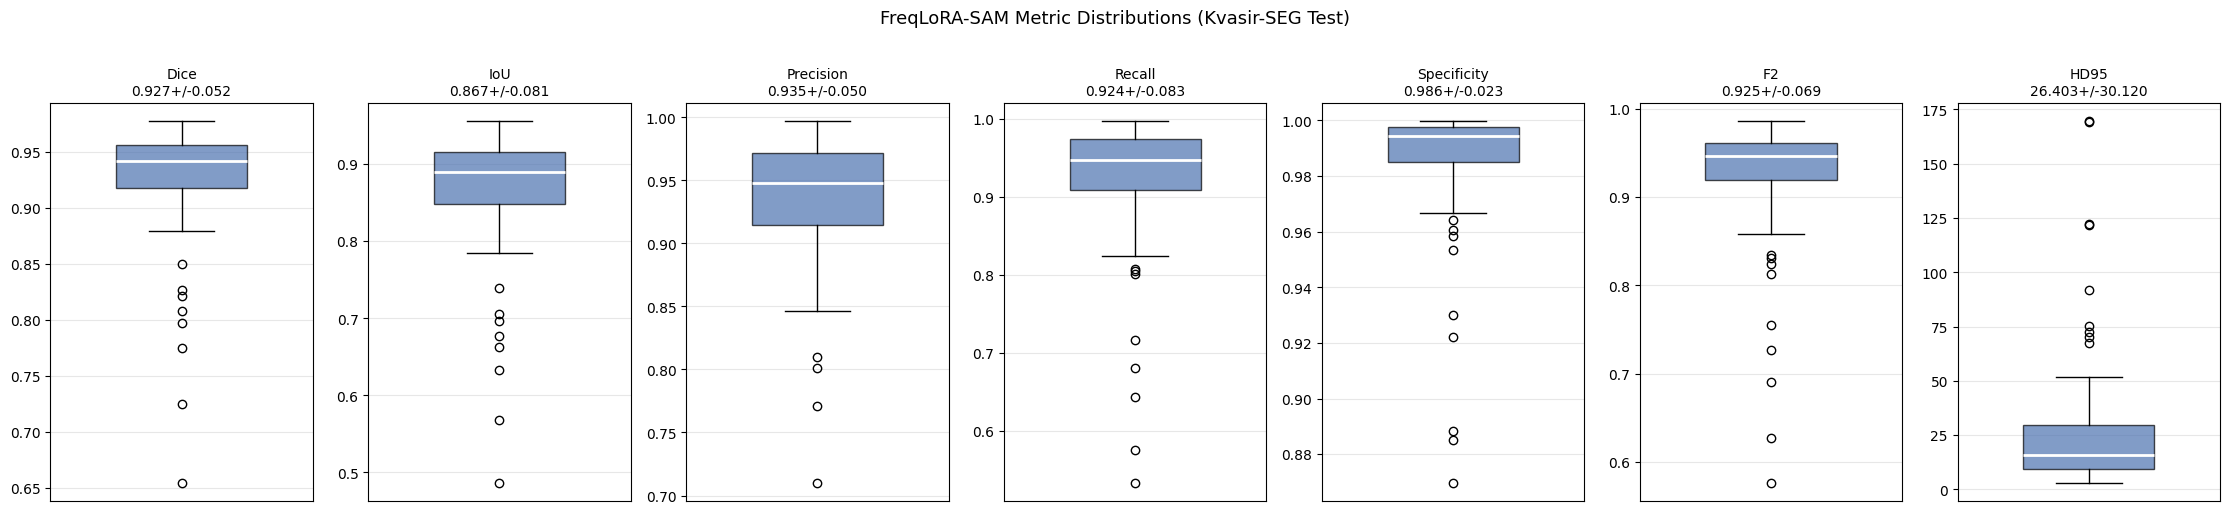

In [13]:
# ============================================================
# Metric box plots (Kvasir-SEG test, best FreqLoRA)
# ============================================================
fig, axes = plt.subplots(1, len(METRIC_COLS), figsize=(3.2 * len(METRIC_COLS), 5))
for ax, m in zip(axes, METRIC_COLS):
    v = df_tta[m].dropna().values
    ax.boxplot(v, patch_artist=True, widths=0.5,
               boxprops=dict(facecolor="#4C72B0", alpha=0.7),
               medianprops=dict(color="white", linewidth=2))
    ax.set_title(f"{m}\n{v.mean():.3f}+/-{v.std():.3f}", fontsize=10)
    ax.set_xticks([]); ax.grid(True, alpha=0.3)
plt.suptitle("FreqLoRA-SAM Metric Distributions (Kvasir-SEG Test)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("metric_boxplots.png", dpi=150, bbox_inches="tight"); plt.show()

---
# Part D — Cross-Dataset Generalization

In [14]:
# ============================================================
# Load best FreqLoRA model + cross-dataset evaluation
# ============================================================
# Rebuild model for cross-dataset eval
random.seed(best_run["seed"])
np.random.seed(best_run["seed"])
torch.manual_seed(best_run["seed"])

sam = sam_model_registry["vit_t"](checkpoint=TINY_CKPT).to(DEVICE)
for p in sam.parameters():
    p.requires_grad = False
lora_layers = inject_adapters(
    sam.image_encoder, rank=LORA_RANK, alpha=LORA_ALPHA,
    dropout=LORA_DROPOUT, mode="freqlora"
)
sam.to(DEVICE)
sam.load_state_dict(torch.load(best_run["ckpt_path"], map_location=DEVICE))
sam.eval()
print(f"Loaded best FreqLoRA model (seed={best_run['seed']})")

# Build cross-dataset loaders
cross_loaders = OrderedDict()
for ds_name, paths in CROSS_DATASETS.items():
    if not os.path.isdir(paths['img_dir']) or not os.path.isdir(paths['mask_dir']):
        print(f"  SKIPPING {ds_name}")
        continue
    ds = PolypDataset(paths['img_dir'], paths['mask_dir'], augment=False)
    cross_loaders[ds_name] = DataLoader(ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
    print(f"  {ds_name}: {len(ds)} images")

# Evaluate
cross_results = OrderedDict()
for ds_name, loader in cross_loaders.items():
    results = []
    for (image_t, points_t, labels_t, mask_t, (H, W), name) in tqdm(loader, desc=ds_name):
        gt01 = (mask_t[0].numpy() > 0.5).astype(np.uint8)
        logits = predict_tta(sam, image_t[0], points_t[0], labels_t[0], (H, W))
        probs = torch.sigmoid(logits)[0, 0].cpu().numpy()
        pred = postprocess((probs > 0.5).astype(np.uint8))
        m = compute_metrics(pred, gt01)
        m["name"] = name[0]; m["dataset"] = ds_name
        results.append(m)
    cross_results[ds_name] = pd.DataFrame(results)
    d = cross_results[ds_name]["Dice"]
    print(f"  {ds_name}: Dice={d.mean():.4f}+/-{d.std():.4f}")

df_cross_all = pd.concat(list(cross_results.values()), ignore_index=True)
cross_ds_names = list(cross_results.keys())
n_cross = len(cross_ds_names)

Loaded best FreqLoRA model (seed=42)
  CVC-ClinicDB: 612 images
  CVC-ColonDB: 380 images
  ETIS-LaribPolypDB: 196 images


CVC-ClinicDB: 100%|██████████| 612/612 [03:39<00:00,  2.79it/s]


  CVC-ClinicDB: Dice=0.8543+/-0.1301


CVC-ColonDB: 100%|██████████| 380/380 [02:24<00:00,  2.64it/s]


  CVC-ColonDB: Dice=0.8448+/-0.1654


ETIS-LaribPolypDB: 100%|██████████| 196/196 [01:28<00:00,  2.21it/s]

  ETIS-LaribPolypDB: Dice=0.7957+/-0.1794


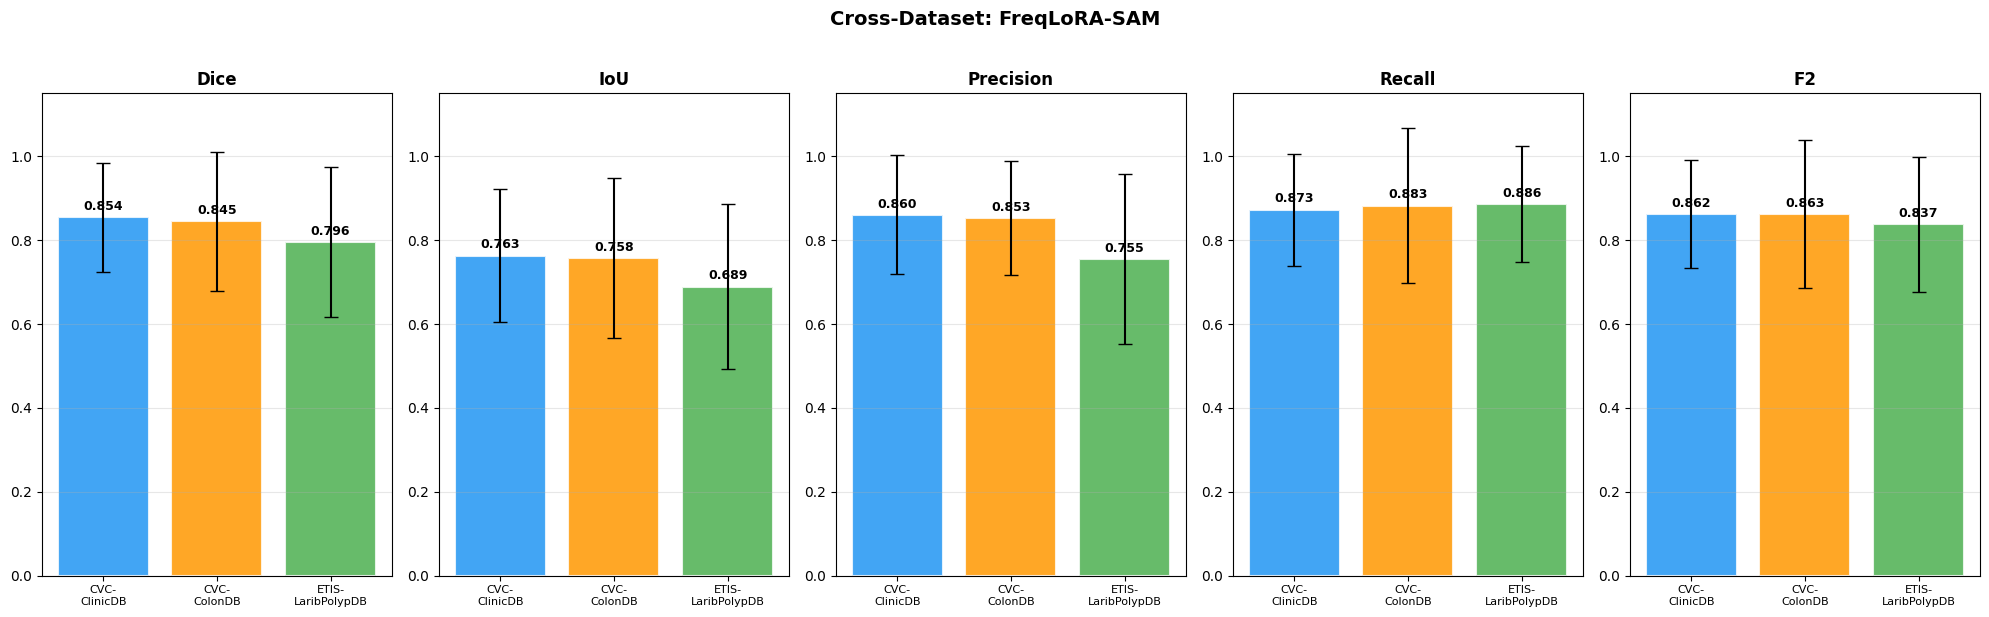

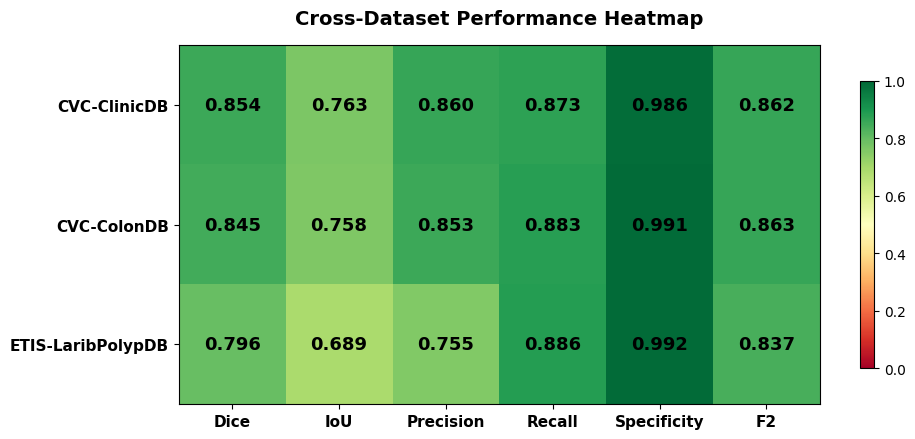

In [15]:
# ============================================================
# Cross-dataset bar charts + heatmap
# ============================================================
colors_cross = ['#2196F3', '#FF9800', '#4CAF50'][:n_cross]

plot_metrics = ["Dice", "IoU", "Precision", "Recall", "F2"]
fig, axes = plt.subplots(1, len(plot_metrics), figsize=(4 * len(plot_metrics), 6))
for ax, metric in zip(axes, plot_metrics):
    means = [cross_results[ds][metric].dropna().mean() for ds in cross_ds_names]
    stds  = [cross_results[ds][metric].dropna().std()  for ds in cross_ds_names]
    bars = ax.bar(range(n_cross), means, yerr=stds, color=colors_cross,
                  capsize=5, edgecolor='white', linewidth=1.5, alpha=0.85)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(range(n_cross))
    xlabels = [n.replace('CVC-', 'CVC-\n').replace('ETIS-', 'ETIS-\n') for n in cross_ds_names]
    ax.set_xticklabels(xlabels, fontsize=8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.15); ax.grid(axis='y', alpha=0.3)
plt.suptitle('Cross-Dataset: FreqLoRA-SAM', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig("cross_dataset_bars.png", dpi=150, bbox_inches="tight"); plt.show()

# Heatmap
heatmap_metrics = ["Dice", "IoU", "Precision", "Recall", "Specificity", "F2"]
data_matrix = np.zeros((n_cross, len(heatmap_metrics)))
for i, ds_name in enumerate(cross_ds_names):
    for j, m in enumerate(heatmap_metrics):
        data_matrix[i, j] = cross_results[ds_name][m].dropna().mean()

fig, ax = plt.subplots(figsize=(10, max(4, n_cross * 1.5)))
im = ax.imshow(data_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
for i in range(n_cross):
    for j in range(len(heatmap_metrics)):
        val = data_matrix[i, j]
        color = 'white' if val < 0.5 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=13, fontweight='bold', color=color)
ax.set_xticks(range(len(heatmap_metrics))); ax.set_xticklabels(heatmap_metrics, fontsize=11, fontweight='bold')
ax.set_yticks(range(n_cross)); ax.set_yticklabels(cross_ds_names, fontsize=11, fontweight='bold')
ax.set_title('Cross-Dataset Performance Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout()
plt.savefig("cross_dataset_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

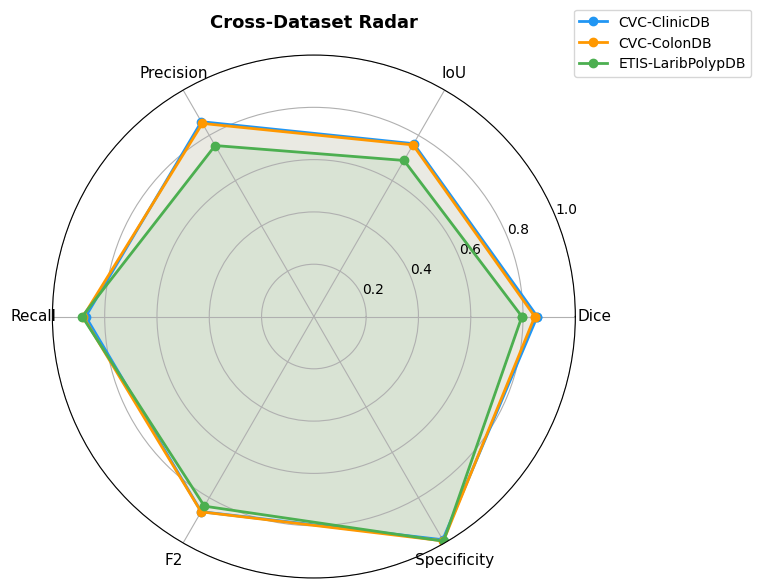

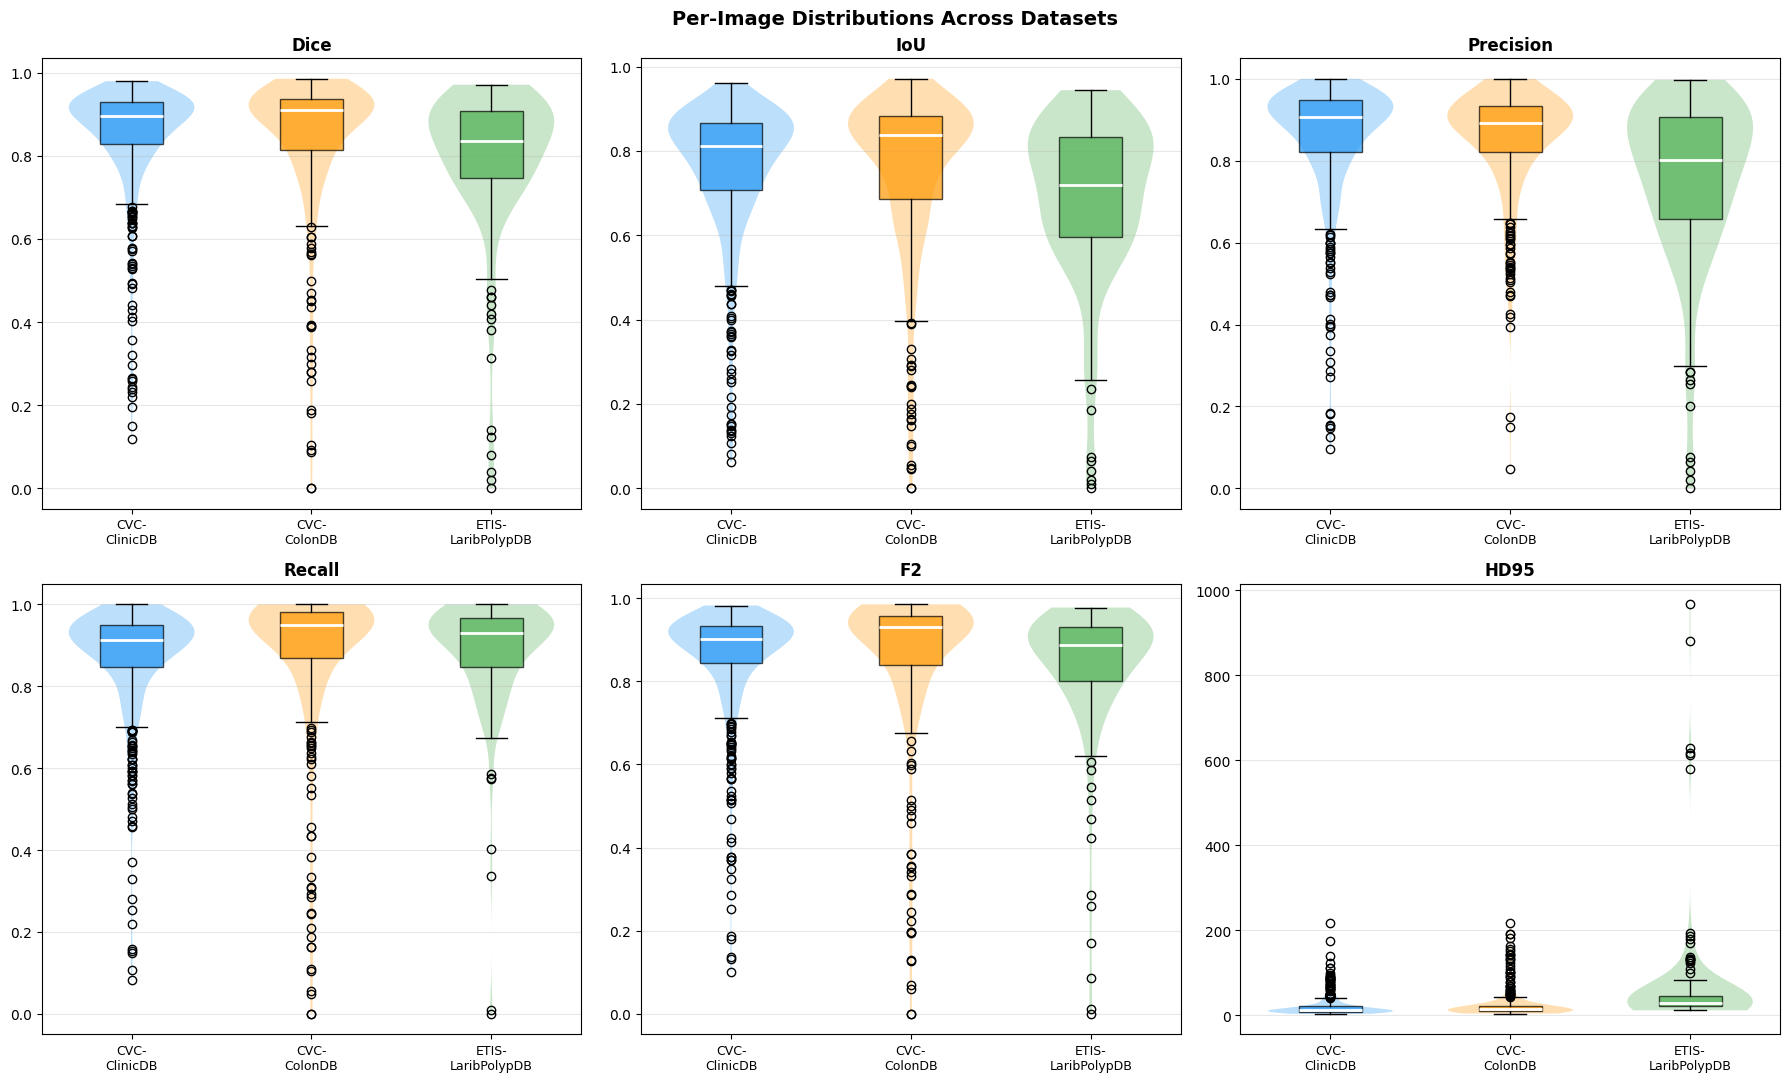

In [16]:
# ============================================================
# Cross-dataset: radar chart + box/violin plots
# ============================================================
# Radar
radar_metrics = ["Dice", "IoU", "Precision", "Recall", "F2", "Specificity"]
N_m = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N_m, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i, ds_name in enumerate(cross_ds_names):
    vals = [cross_results[ds_name][m].dropna().mean() for m in radar_metrics] + \
           [cross_results[ds_name][radar_metrics[0]].dropna().mean()]
    ax.plot(angles, vals, 'o-', linewidth=2, label=ds_name, color=colors_cross[i], markersize=6)
    ax.fill(angles, vals, alpha=0.1, color=colors_cross[i])
ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_metrics, fontsize=11)
ax.set_ylim(0, 1); ax.set_title('Cross-Dataset Radar', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout(); plt.savefig("cross_dataset_radar.png", dpi=150, bbox_inches="tight"); plt.show()

# Box + violin
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
box_metrics = ["Dice", "IoU", "Precision", "Recall", "F2", "HD95"]
for ax, metric in zip(axes.flat, box_metrics):
    data = [cross_results[ds][metric].dropna().values for ds in cross_ds_names]
    parts = ax.violinplot(data, positions=range(n_cross), showmedians=False, showextrema=False, widths=0.7)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors_cross[i]); pc.set_alpha(0.3)
    bp = ax.boxplot(data, positions=range(n_cross), widths=0.35, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2))
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(colors_cross[i]); patch.set_alpha(0.7)
    ax.set_xticks(range(n_cross))
    ax.set_xticklabels([n.replace('CVC-','CVC-\n').replace('ETIS-','ETIS-\n') for n in cross_ds_names], fontsize=9)
    ax.set_title(metric, fontsize=12, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
plt.suptitle('Per-Image Distributions Across Datasets', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig("cross_dataset_boxplots.png", dpi=150, bbox_inches="tight"); plt.show()

---
# Part E — Aggregated Results: Ablation Table + Multi-Seed Statistics

In [17]:
# ============================================================
# Multi-seed ablation table
# ============================================================
print("=" * 90)
print("  MULTI-SEED ABLATION TABLE (Kvasir-SEG Test, TTA + Post-proc)")
print("=" * 90)

ablation_rows = []
for mode in ABLATION_MODES:
    runs = [r for r in all_experiments if r["mode"] == mode]
    dices = [r["test_dice_mean"] for r in runs]
    ious  = [r["test_iou_mean"]  for r in runs]
    precs = [r["test_prec_mean"] for r in runs]
    recs  = [r["test_rec_mean"]  for r in runs]
    f2s   = [r["test_f2_mean"]   for r in runs]
    hd95s = [r["test_hd95_mean"] for r in runs]

    row = {
        "Mode": mode,
        "Dice": f"{np.mean(dices):.4f}+/-{np.std(dices):.4f}",
        "IoU":  f"{np.mean(ious):.4f}+/-{np.std(ious):.4f}",
        "Prec": f"{np.mean(precs):.4f}+/-{np.std(precs):.4f}",
        "Rec":  f"{np.mean(recs):.4f}+/-{np.std(recs):.4f}",
        "F2":   f"{np.mean(f2s):.4f}+/-{np.std(f2s):.4f}",
        "HD95": f"{np.mean(hd95s):.1f}+/-{np.std(hd95s):.1f}",
        "Dice_mean": np.mean(dices),
        "Dice_seeds": dices,
    }
    ablation_rows.append(row)

# Print table
print(f"\n  {'Mode':<12} {'Dice':>20} {'IoU':>20} {'Prec':>20} {'Rec':>20}")
print(f"  {'-'*12} {'-'*20} {'-'*20} {'-'*20} {'-'*20}")
for row in ablation_rows:
    print(f"  {row['Mode']:<12} {row['Dice']:>20} {row['IoU']:>20} {row['Prec']:>20} {row['Rec']:>20}")

# Per-seed breakdown
print(f"\n\n  Per-seed breakdown (Dice):")
print(f"  {'Mode':<12}", end="")
for s in SEEDS:
    print(f"  seed={s:>5}", end="")
print(f"  {'Mean':>8} {'Std':>8}")
print(f"  {'-'*12}", end="")
for _ in SEEDS:
    print(f"  {'-'*10}", end="")
print(f"  {'-'*8} {'-'*8}")

for row in ablation_rows:
    print(f"  {row['Mode']:<12}", end="")
    for d in row['Dice_seeds']:
        print(f"  {d:>10.4f}", end="")
    print(f"  {row['Dice_mean']:>8.4f} {np.std(row['Dice_seeds']):>8.4f}")

# Statistical test: freqlora vs spatial
print(f"\n\n  --- Statistical comparison (paired t-test on seed-matched Dice) ---")
spatial_dices   = [r["test_dice_mean"] for r in all_experiments if r["mode"] == "spatial"]
freqlora_dices  = [r["test_dice_mean"] for r in all_experiments if r["mode"] == "freqlora"]
freq_only_dices = [r["test_dice_mean"] for r in all_experiments if r["mode"] == "freq_only"]

if len(spatial_dices) == len(freqlora_dices) == len(SEEDS):
    t_stat, p_val = stats.ttest_rel(freqlora_dices, spatial_dices)
    print(f"  FreqLoRA vs Spatial: t={t_stat:.4f}, p={p_val:.4f} {'(significant)' if p_val < 0.05 else '(not significant)'}")
    t_stat2, p_val2 = stats.ttest_rel(freqlora_dices, freq_only_dices)
    print(f"  FreqLoRA vs FreqOnly: t={t_stat2:.4f}, p={p_val2:.4f} {'(significant)' if p_val2 < 0.05 else '(not significant)'}")
print("=" * 90)

  MULTI-SEED ABLATION TABLE (Kvasir-SEG Test, TTA + Post-proc)

  Mode                         Dice                  IoU                 Prec                  Rec
  ------------ -------------------- -------------------- -------------------- --------------------
  spatial           0.9188+/-0.0081      0.8586+/-0.0106      0.9257+/-0.0134      0.9245+/-0.0048
  freq_only         0.9205+/-0.0084      0.8617+/-0.0108      0.9260+/-0.0133      0.9274+/-0.0054
  freqlora          0.9201+/-0.0085      0.8609+/-0.0110      0.9245+/-0.0112      0.9276+/-0.0048


  Per-seed breakdown (Dice):
  Mode          seed=   42  seed=  123  seed=  777      Mean      Std
  ------------  ----------  ----------  ----------  -------- --------
  spatial           0.9244      0.9245      0.9073    0.9188   0.0081
  freq_only         0.9267      0.9262      0.9087    0.9205   0.0084
  freqlora          0.9265      0.9258      0.9081    0.9201   0.0085


  --- Statistical comparison (paired t-test on seed-matche

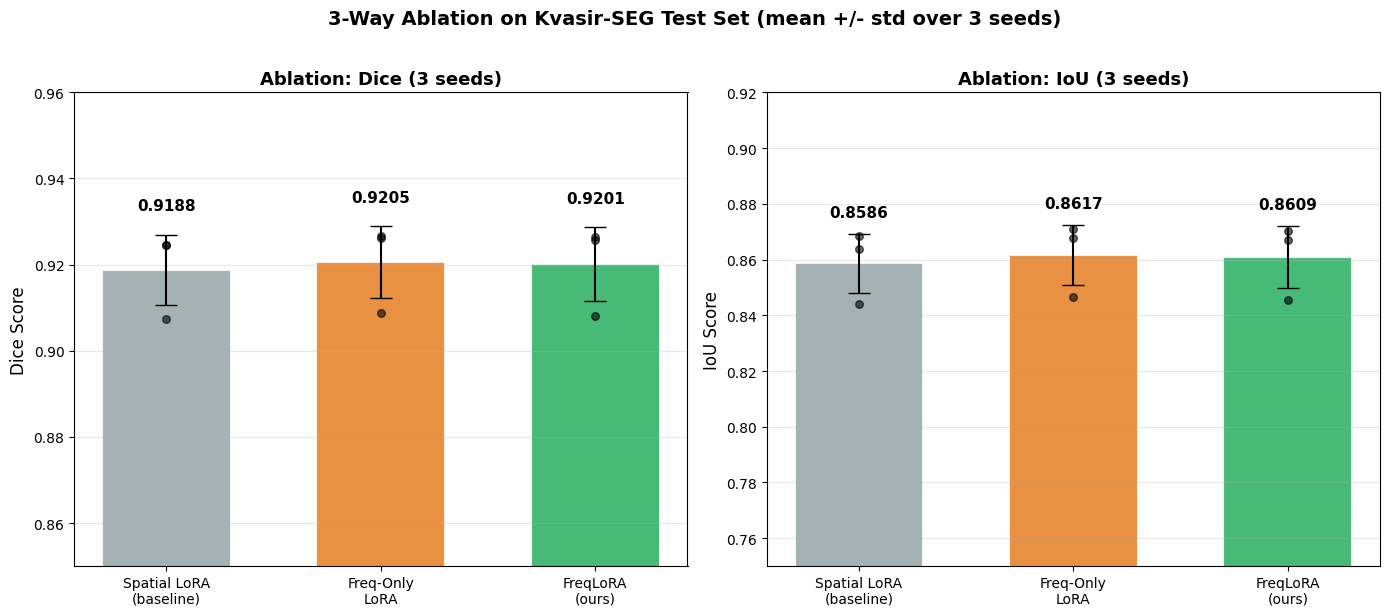

In [18]:
# ============================================================
# Ablation bar chart
# ============================================================
mode_labels = {"spatial": "Spatial LoRA\n(baseline)", "freq_only": "Freq-Only\nLoRA", "freqlora": "FreqLoRA\n(ours)"}
mode_colors = {"spatial": "#95a5a6", "freq_only": "#e67e22", "freqlora": "#27ae60"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Dice
ax = axes[0]
for i, mode in enumerate(ABLATION_MODES):
    runs = [r for r in all_experiments if r["mode"] == mode]
    dices = [r["test_dice_mean"] for r in runs]
    ax.bar(i, np.mean(dices), yerr=np.std(dices), color=mode_colors[mode],
           capsize=8, edgecolor='white', linewidth=1.5, alpha=0.85, width=0.6)
    ax.text(i, np.mean(dices) + np.std(dices) + 0.005,
            f"{np.mean(dices):.4f}", ha='center', va='bottom', fontsize=11, fontweight='bold')
    # Plot individual seeds
    for j, d in enumerate(dices):
        ax.scatter(i, d, color='black', s=30, zorder=5, alpha=0.6)
ax.set_xticks(range(len(ABLATION_MODES)))
ax.set_xticklabels([mode_labels[m] for m in ABLATION_MODES], fontsize=10)
ax.set_ylabel("Dice Score", fontsize=12)
ax.set_title("Ablation: Dice (3 seeds)", fontsize=13, fontweight='bold')
ax.set_ylim(0.85, 0.96); ax.grid(axis='y', alpha=0.3)

# IoU
ax = axes[1]
for i, mode in enumerate(ABLATION_MODES):
    runs = [r for r in all_experiments if r["mode"] == mode]
    ious = [r["test_iou_mean"] for r in runs]
    ax.bar(i, np.mean(ious), yerr=np.std(ious), color=mode_colors[mode],
           capsize=8, edgecolor='white', linewidth=1.5, alpha=0.85, width=0.6)
    ax.text(i, np.mean(ious) + np.std(ious) + 0.005,
            f"{np.mean(ious):.4f}", ha='center', va='bottom', fontsize=11, fontweight='bold')
    for j, d in enumerate(ious):
        ax.scatter(i, d, color='black', s=30, zorder=5, alpha=0.6)
ax.set_xticks(range(len(ABLATION_MODES)))
ax.set_xticklabels([mode_labels[m] for m in ABLATION_MODES], fontsize=10)
ax.set_ylabel("IoU Score", fontsize=12)
ax.set_title("Ablation: IoU (3 seeds)", fontsize=13, fontweight='bold')
ax.set_ylim(0.75, 0.92); ax.grid(axis='y', alpha=0.3)

plt.suptitle("3-Way Ablation on Kvasir-SEG Test Set (mean +/- std over 3 seeds)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig("ablation_chart.png", dpi=150, bbox_inches="tight"); plt.show()

FreqLoRA Gate Analysis (best run):
  gate=1.0 -> pure spatial | gate=0.0 -> pure frequency

  head                      gate=0.5000 (balanced)
  attn.qkv                  gate=0.4292 (balanced)
  attn.proj                 gate=0.4522 (balanced)
  mlp.fc1                   gate=0.4190 (balanced)
  mlp.fc2                   gate=0.4511 (balanced)
  attn.qkv                  gate=0.4528 (balanced)
  attn.proj                 gate=0.4806 (balanced)
  mlp.fc1                   gate=0.4253 (balanced)
  mlp.fc2                   gate=0.4899 (balanced)
  attn.qkv                  gate=0.4395 (balanced)
  attn.proj                 gate=0.5242 (balanced)
  mlp.fc1                   gate=0.5051 (balanced)
  mlp.fc2                   gate=0.4972 (balanced)
  attn.qkv                  gate=0.4887 (balanced)
  attn.proj                 gate=0.4364 (balanced)
  mlp.fc1                   gate=0.5437 (balanced)
  mlp.fc2                   gate=0.4900 (balanced)
  attn.qkv                  gate=0.4866 (

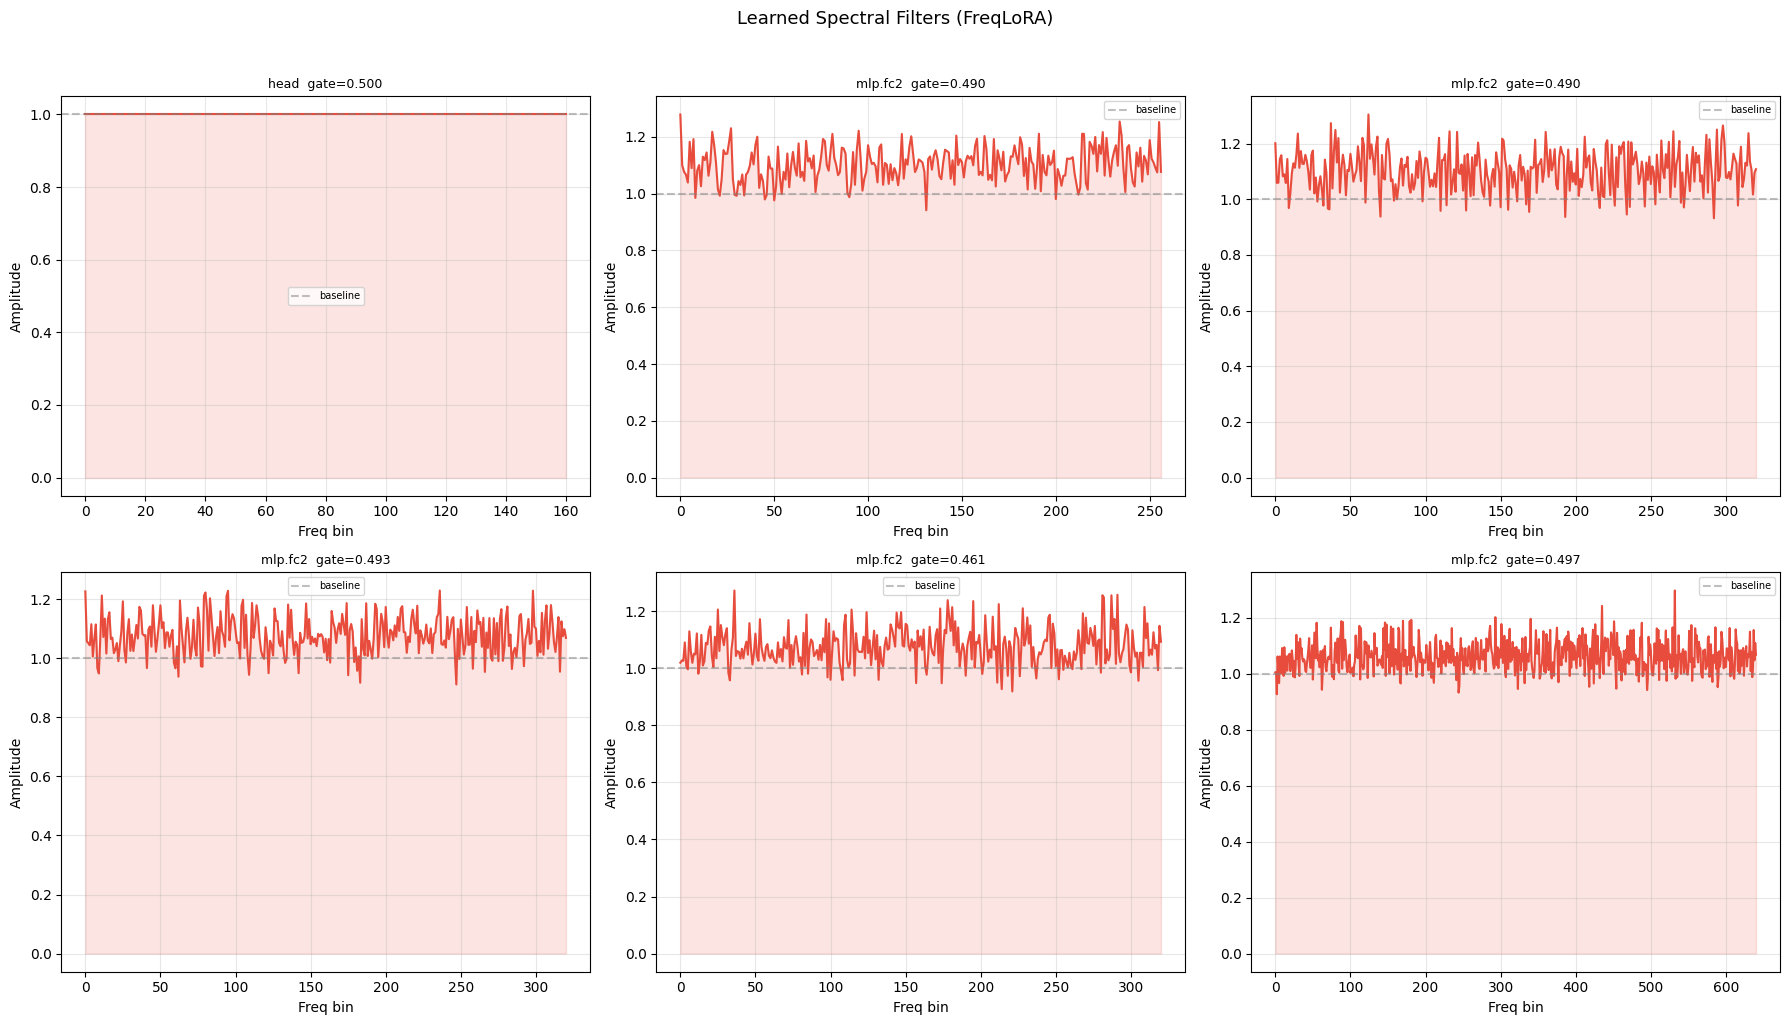

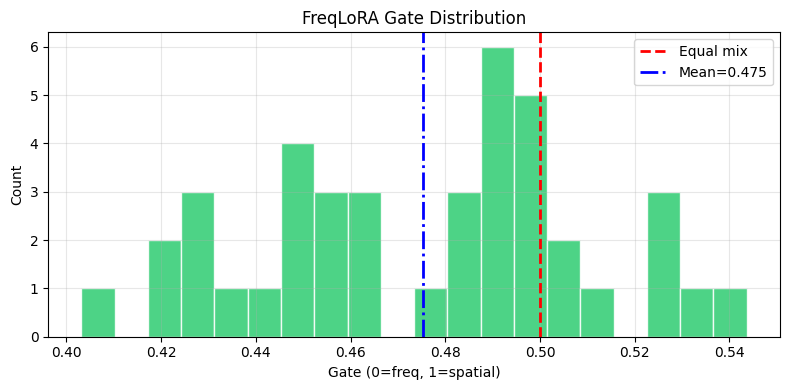

In [19]:
# ============================================================
# FreqLoRA gate analysis (from best run)
# ============================================================
# Reload for gate analysis
sam_gate = sam_model_registry["vit_t"](checkpoint=TINY_CKPT).to(DEVICE)
for p in sam_gate.parameters():
    p.requires_grad = False
lora_layers_gate = inject_adapters(sam_gate.image_encoder, rank=LORA_RANK, alpha=LORA_ALPHA,
                                    dropout=LORA_DROPOUT, mode="freqlora")
sam_gate.to(DEVICE)
sam_gate.load_state_dict(torch.load(best_run["ckpt_path"], map_location=DEVICE))
sam_gate.eval()

print("FreqLoRA Gate Analysis (best run):")
print(f"  gate=1.0 -> pure spatial | gate=0.0 -> pure frequency\n")

gate_data = []
for lname, layer in lora_layers_gate:
    g = torch.sigmoid(layer.gate_param).item()
    gate_data.append({"layer": lname, "gate": g,
                      "in_features": layer.in_features, "out_features": layer.out_features})
    dom = 'spatial' if g > 0.6 else 'freq' if g < 0.4 else 'balanced'
    # Shorten name for display
    parts = lname.split(".")
    short = ".".join(parts[-2:]) if len(parts) >= 2 else lname
    print(f"  {short:25s} gate={g:.4f} ({dom})")

df_gate = pd.DataFrame(gate_data)
print(f"\n  Mean: {df_gate['gate'].mean():.4f} | Std: {df_gate['gate'].std():.4f}")

# Spectral filter vis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
plot_idx = np.linspace(0, len(lora_layers_gate)-1, min(6, len(lora_layers_gate)), dtype=int)

for ax_i, li in enumerate(plot_idx):
    lname, layer = lora_layers_gate[li]
    sf = layer.spectral_filter.detach().cpu().numpy()
    gate = torch.sigmoid(layer.gate_param).item()
    ax = axes[ax_i]
    ax.plot(sf, color="#E74C3C", lw=1.5)
    ax.axhline(y=1.0, color="gray", ls="--", alpha=0.5, label="baseline")
    ax.fill_between(range(len(sf)), sf, alpha=0.15, color="#E74C3C")
    ax.set_xlabel("Freq bin"); ax.set_ylabel("Amplitude")
    parts = lname.split(".")
    short = ".".join(parts[-2:]) if len(parts) >= 2 else lname
    ax.set_title(f"{short}  gate={gate:.3f}", fontsize=9)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle("Learned Spectral Filters (FreqLoRA)", fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig("freqlora_spectral.png", dpi=150, bbox_inches="tight"); plt.show()

# Gate histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_gate["gate"].values, bins=20, color="#2ECC71", edgecolor="white", alpha=0.85)
ax.axvline(0.5, color="red", ls="--", lw=2, label="Equal mix")
ax.axvline(df_gate["gate"].mean(), color="blue", ls="-.", lw=2, label=f"Mean={df_gate['gate'].mean():.3f}")
ax.set_xlabel("Gate (0=freq, 1=spatial)"); ax.set_ylabel("Count")
ax.set_title("FreqLoRA Gate Distribution"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("freqlora_gates.png", dpi=150, bbox_inches="tight"); plt.show()

del sam_gate
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

In [20]:
# ============================================================
# Save everything
# ============================================================
output_dir = "/kaggle/working"

# Ablation summary
ablation_save = []
for r in all_experiments:
    ablation_save.append({
        "mode": r["mode"], "seed": r["seed"],
        "val_dice": r["best_val_dice"],
        "test_dice": r["test_dice_mean"], "test_dice_std": r["test_dice_std"],
        "test_iou": r["test_iou_mean"], "test_iou_std": r["test_iou_std"],
        "test_prec": r["test_prec_mean"], "test_rec": r["test_rec_mean"],
        "test_f2": r["test_f2_mean"], "test_hd95": r["test_hd95_mean"],
    })
pd.DataFrame(ablation_save).to_csv(os.path.join(output_dir, "ablation_all_runs.csv"), index=False)

# Best run Kvasir test
df_tta.to_csv(os.path.join(output_dir, "kvasir_test_results.csv"), index=False)

# Cross-dataset
df_cross_all.to_csv(os.path.join(output_dir, "cross_dataset_all_results.csv"), index=False)
for ds_name, df in cross_results.items():
    safe = ds_name.lower().replace('-', '_').replace(' ', '_')
    df.to_csv(os.path.join(output_dir, f"results_{safe}.csv"), index=False)

# Gate analysis
df_gate.to_csv(os.path.join(output_dir, "freqlora_gate_analysis.csv"), index=False)

# ════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════════
print("=" * 80)
print("  FINAL SUMMARY")
print("=" * 80)

print("\n  --- Ablation (mean across 3 seeds) ---")
print(f"  {'Mode':<12} {'Dice':>10} {'IoU':>10}")
print(f"  {'-'*12} {'-'*10} {'-'*10}")
for mode in ABLATION_MODES:
    runs = [r for r in all_experiments if r["mode"] == mode]
    d = np.mean([r["test_dice_mean"] for r in runs])
    iou = np.mean([r["test_iou_mean"] for r in runs])
    print(f"  {mode:<12} {d:>10.4f} {iou:>10.4f}")

print(f"\n  --- Cross-Dataset (best FreqLoRA, seed={best_run['seed']}) ---")
print(f"  {'Dataset':<22} {'N':>6} {'Dice':>10} {'IoU':>10}")
print(f"  {'-'*22} {'-'*6} {'-'*10} {'-'*10}")
print(f"  {'Kvasir-SEG (test)':<22} {len(df_tta):>6} "
      f"{df_tta['Dice'].mean():>10.4f} {df_tta['IoU'].mean():>10.4f}")
for ds_name, df in cross_results.items():
    print(f"  {ds_name:<22} {len(df):>6} "
          f"{df['Dice'].mean():>10.4f} {df['IoU'].mean():>10.4f}")
print(f"  {'Overall cross-dataset':<22} {len(df_cross_all):>6} "
      f"{df_cross_all['Dice'].mean():>10.4f} {df_cross_all['IoU'].mean():>10.4f}")

print(f"\n{'='*80}")
print("  Done! All results saved. Ready for paper.")
print(f"{'='*80}")

  FINAL SUMMARY

  --- Ablation (mean across 3 seeds) ---
  Mode               Dice        IoU
  ------------ ---------- ----------
  spatial          0.9188     0.8586
  freq_only        0.9205     0.8617
  freqlora         0.9201     0.8609

  --- Cross-Dataset (best FreqLoRA, seed=42) ---
  Dataset                     N       Dice        IoU
  ---------------------- ------ ---------- ----------
  Kvasir-SEG (test)         100     0.9265     0.8670
  CVC-ClinicDB              612     0.8543     0.7633
  CVC-ColonDB               380     0.8448     0.7580
  ETIS-LaribPolypDB         196     0.7957     0.6892
  Overall cross-dataset    1188     0.8416     0.7494

  Done! All results saved. Ready for paper.
